### EDA

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pandas.api.types import is_numeric_dtype, is_string_dtype, is_datetime64_any_dtype
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split

PARENT_DIRECTORY_1 = Path.cwd().parent.parent.parent
sys.path.append(f"{str(PARENT_DIRECTORY_1)}")

from EDA.utils.classifications import EDAClasificacion

#### Problem Framing

- Unidad de predicción: Cliente
- Target: 'SeriousDlqin2yrs'
- Plazo: 24 meses
- Días: 90 días
- Nivel: Préstamo personal
- Momento de la predicción: Uso a partir de finales de Agosto 2026
- Información Disponible: Todas las features están disponibles al momento de la predicción
- Información No Disponible: Ninguna
- Acción de Negocio: Aprobar o Rechazar a los clientes según su probabilidad de incumplir el préstamo
- Horizonte de la predicción: 24 meses
- Métricas Técnicas: AUC / Gini / Calibration
- Métricas de Negocio: Tasa de incumplimientos / Renevue por préstamos personales

In [2]:
df_train = pd.read_csv('../data/raw/cs-training.csv', index_col=0)
df_test = pd.read_csv('../data/raw/cs-test.csv', index_col=0)

In [3]:
df_train.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

No hay features categóricas en el dataset

Data Overview



,Data Overview
Filas,150000
Columnas,11
Features Numéricas,11
Features Categóricas,0
Features Datetime,0
Features Booleanas,0
Missing Global (%),33655
Features con Missing,2
Features > 20% Missing,2
Filas Duplicadas,609



Inventario de Features



,feature,dtype,semantic_dtype,missing_pct,unique_values,cardinality_group,is_constant,is_near_constant
10,NumberOfDependents,float64,Continua,2.62%,13,---,False,False
5,MonthlyIncome,float64,Continua,19.82%,13594,---,False,False
0,SeriousDlqin2yrs,int64,Conteo,0.00%,2,---,False,True
2,age,int64,Continua,0.00%,86,---,False,False
3,NumberOfTime30-59DaysPastDueNotWorse,int64,Conteo,0.00%,16,---,False,False
6,NumberOfOpenCreditLinesAndLoans,int64,Continua,0.00%,58,---,False,False
7,NumberOfTimes90DaysLate,int64,Conteo,0.00%,19,---,False,False
8,NumberRealEstateLoansOrLines,int64,Conteo,0.00%,28,---,False,False
9,NumberOfTime60-89DaysPastDueNotWorse,int64,Conteo,0.00%,13,---,False,False
1,RevolvingUtilizationOfUnsecuredLines,float64,Continua,0.00%,125728,---,False,False



Analisis de Missing



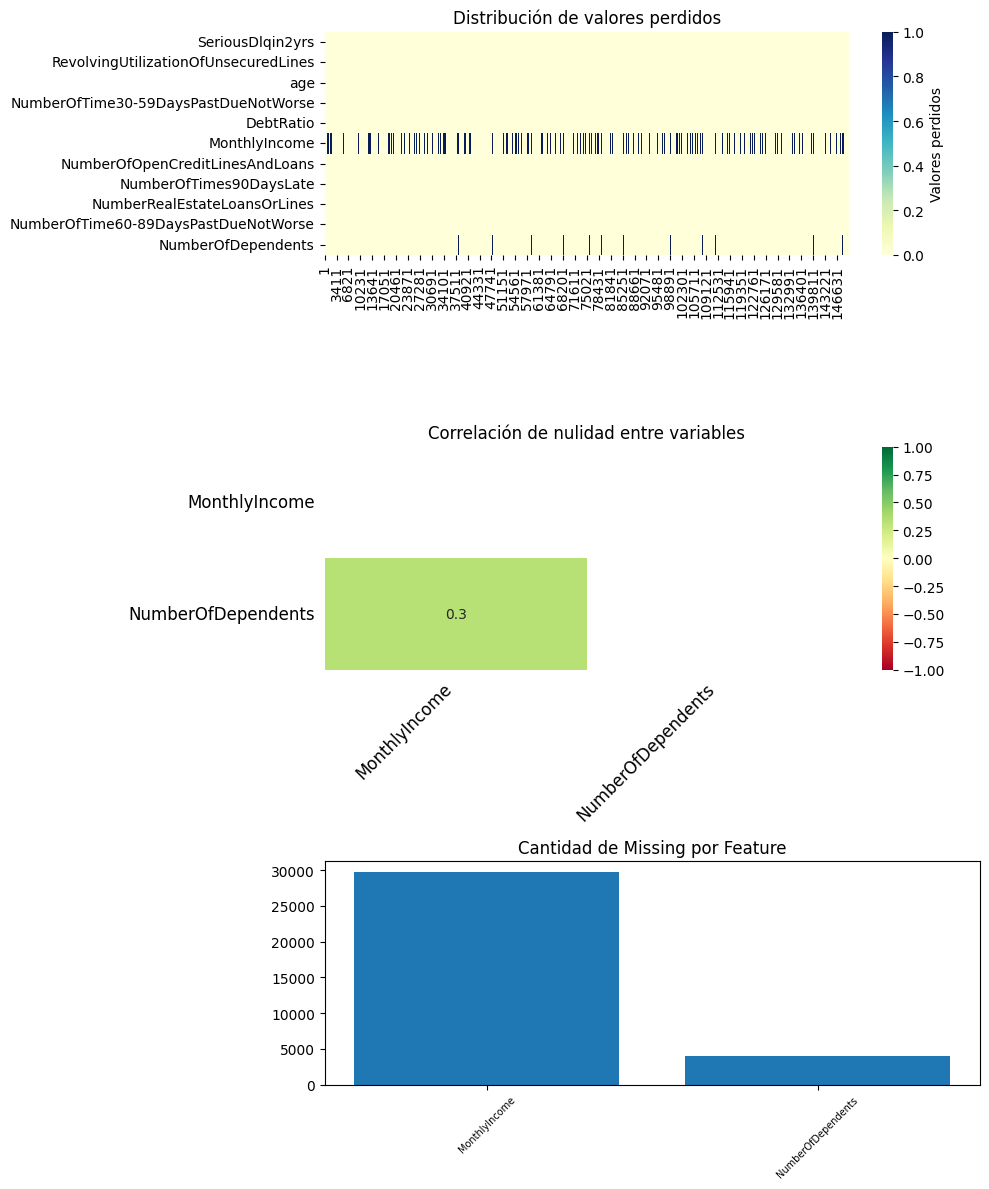


Detector de Outliers - IQR



,Feature,Límite Superior,Límite Inferior,Reg. Fuera del Rango,% Reg. Fuera del Rango
2,DebtRatio,1.908024,-0.864696,31311,20.87%
5,NumberOfDependents,2.500000,-1.500000,13336,8.89%
3,MonthlyIncome,15522.500000,-3873.500000,4879,3.25%
4,NumberOfOpenCreditLinesAndLoans,20.000000,-4.000000,3980,2.65%
0,RevolvingUtilizationOfUnsecuredLines,1.352814,-0.763901,763,0.51%
1,age,96.000000,8.000000,46,0.03%



Detector de Outlier - Percentiles



,Feature,PCT Min,Valor PCT minimo,PCT Max,Valor PCT maximo,Registros fuera,% Registros fuera
1,age,P0.5,23.0,P99.5,89.00,1305,0.87%
0,RevolvingUtilizationOfUnsecuredLines,P0.5,0.0,P99.5,1.37,750,0.50%
2,DebtRatio,P0.5,0.0,P99.5,6186.01,750,0.50%
4,NumberOfOpenCreditLinesAndLoans,P0.5,0.0,P99.5,27.00,706,0.47%
3,MonthlyIncome,P0.5,0.0,P99.5,35000.00,589,0.39%
5,NumberOfDependents,P0.5,0.0,P99.5,5.00,245,0.16%



Distribucion Feats Numericas



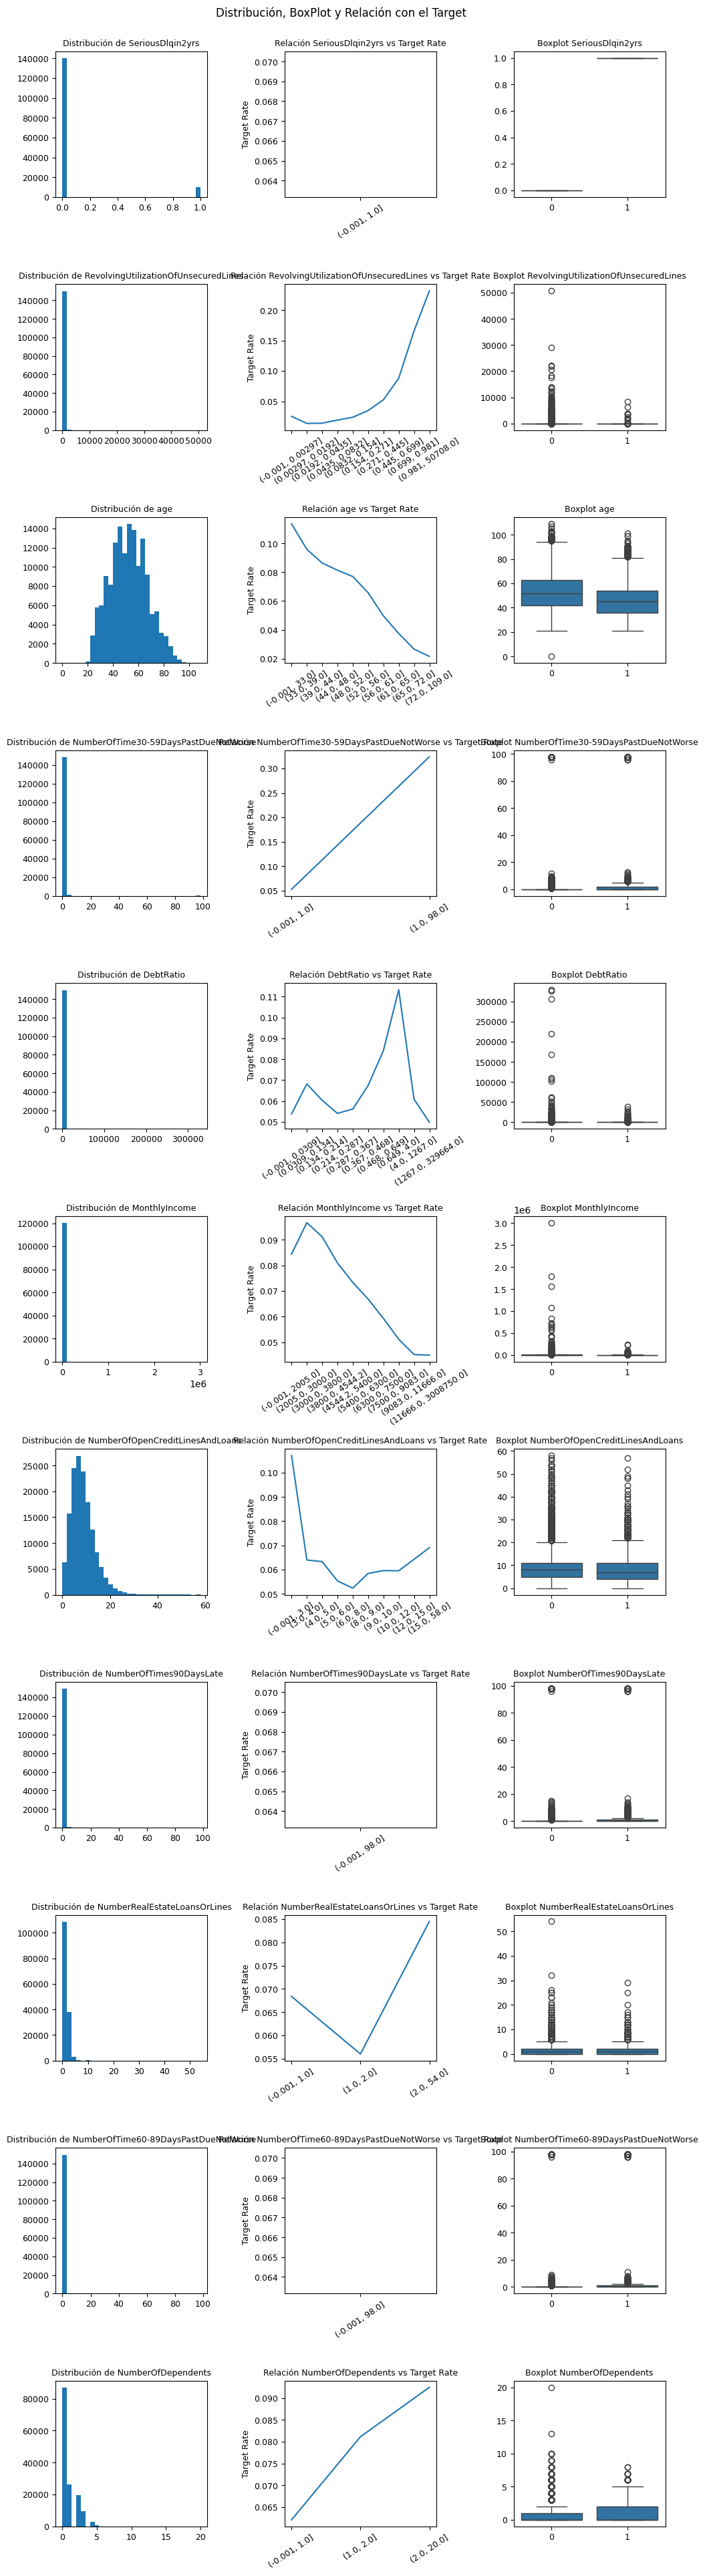


Distribucion Feats Categoricas



None


Analisis del Target - Gráficos



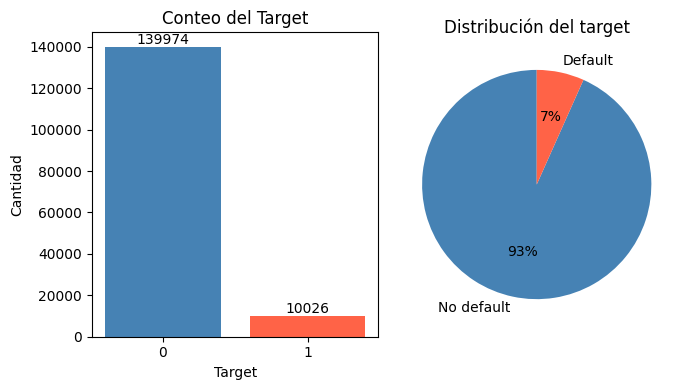


Analisis del Target - Resumen Tabla



,Registros,Missing target,Clases únicas,Positive rate,Negative rate,Imbalance rate,Baseline accuracy,Nivel de desbalance
0,150000,0,2,0.06684,0.93316,13.96:1,93.32%,Desbalanceado



Information Value



,Feature,Information Value
0,RevolvingUtilizationOfUnsecuredLines,1.059550
1,age,0.250022
4,MonthlyIncome,0.076565
3,DebtRatio,0.059485
5,NumberOfOpenCreditLinesAndLoans,0.048021
9,NumberOfDependents,0.024083
7,NumberRealEstateLoansOrLines,0.012090
2,NumberOfTime30-59DaysPastDueNotWorse,0.000000
6,NumberOfTimes90DaysLate,0.000000
8,NumberOfTime60-89DaysPastDueNotWorse,0.000000



Relaciones entre Variables



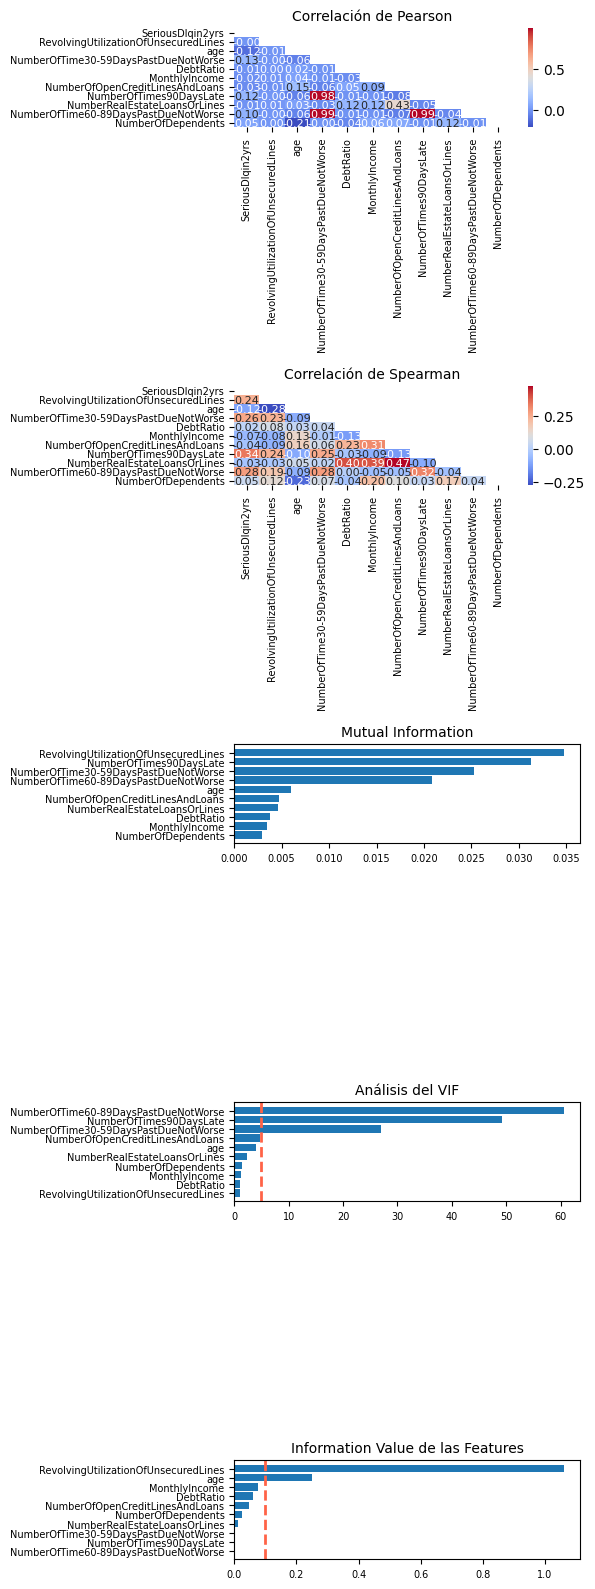


PSI



,feature,type,psi,interpretacion
0,MonthlyIncome,numeric,0.0004,Sin drift
1,RevolvingUtilizationOfUnsecuredLines,numeric,0.0001,Sin drift
2,age,numeric,0.0001,Sin drift
3,DebtRatio,numeric,0.0001,Sin drift
4,NumberOfOpenCreditLinesAndLoans,numeric,0.0001,Sin drift
5,NumberRealEstateLoansOrLines,numeric,0.0001,Sin drift
6,NumberOfDependents,numeric,0.0001,Sin drift
7,NumberOfTime30-59DaysPastDueNotWorse,numeric,0.0000,Sin drift
8,NumberOfTimes90DaysLate,numeric,0.0000,Sin drift
9,NumberOfTime60-89DaysPastDueNotWorse,numeric,0.0000,Sin drift


In [6]:
EDA = EDAClasificacion(
    data=df_train,
    target_name= 'SeriousDlqin2yrs',
    tipo_problema='clasificacion'
)

resultados_eda = EDA.run_all(
    data_comparacion= df_test,
    include_psi=True,
    show=True
)


In [17]:
PATH_MONITORING = Path('../artifacts') / 'monitoring'
PATH_FE = Path('../artifacts') / 'feature_engineering'
PATH_TM = Path('../artifacts') / 'training_model'